In [2]:
!pip install kagglehub

In [3]:
import kagglehub

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

100%|█████████████████████████████████████████████████████████████████████████████| 66.0M/66.0M [00:21<00:00, 3.29MB/s]


Extracting files...
Path to dataset files: C:\Users\HP\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score as ras
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_auc_score


In [60]:
#get the csv file
path = 'C:/Users/HP/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv'

#read the csv and convert it into pandas df
raw_pd_data = pd.read_csv(path)
raw_pd_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


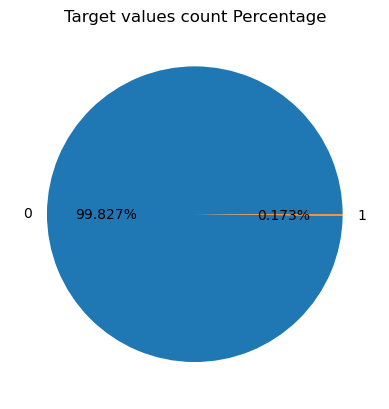

In [62]:
#get the unique values of specific coloum
uni_values = raw_pd_data.Class.unique()

#get the number of each values
num_values = raw_pd_data.Class.value_counts().values

#graph of data or visual representation
fig, ax = plt.subplots()
ax.pie(num_values, labels=uni_values, autopct='%1.3f%%')
ax.set_title("Target values count Percentage")
plt.show()

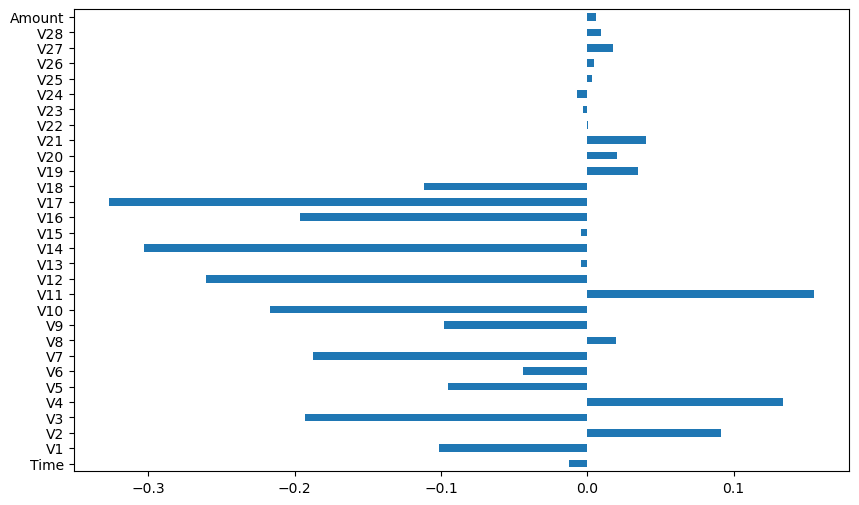

In [64]:
#Correlation of diffrent values to target values
correlation_values = raw_pd_data.corr()['Class'].drop('Class')

#graph of correlation
correlation_values.plot(kind='barh' , figsize=(10,6))
plt.show()

In [65]:
#converting thier values and comparing them to mean
raw_pd_data.iloc[:, 1:30] = StandardScaler().fit_transform(raw_pd_data.iloc[:, 1:30])
np_data = raw_pd_data.values

#data to train X
X = np_data[:, 1:30]

#y the result of data to test
y = np_data[:, 30]

#data normalization
X = normalize(X, "l1")

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

In [67]:

#increasing importance of false values 
w_train = compute_sample_weight('balanced', y_train)

In [74]:
dt = DecisionTreeClassifier(random_state=35, max_depth = 4)

dt.fit(X_train, y_train, sample_weight = w_train)

DecisionTreeClassifier(max_depth=4, random_state=35)

In [75]:
svm = LinearSVC(class_weight='balanced',random_state= 35, fit_intercept=False)

svm.fit(X_train, y_train)

LinearSVC(class_weight='balanced', fit_intercept=False, random_state=35)

In [76]:
#calculating probability by Decision Tree
y_pred_dt = dt.predict_proba(X_test)[:,1]

#testing Decision Tree
roc_auc_dt = roc_auc_score(y_test, y_pred_dt)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_dt))

Decision Tree ROC-AUC score : 0.929


In [78]:
#calculating probability by SVM
y_pred_svm = svm.decision_function(X_test)

#find accuracy
roc_auc_svm = roc_auc_score(y_test, y_pred_svm)
print('Decision Tree ROC-AUC score : {0:.3f}'.format(roc_auc_svm))

Decision Tree ROC-AUC score : 0.962
